## 03. Advanced: Variants, Rework, and Performance Analysis

This notebook extends the BPI Challenge 2019 pipeline with deeper analytics:

| Step | Analysis | Output |
|------|----------|--------|
| 1 | Load & filter data | Clean event log |
| 2 | Variant analysis | Distinct process paths |
| 3 | Variant frequency chart | Fig 03 — Pareto bar chart |
| 4 | Throughput time | Case duration distribution |
| 5 | Throughput histograms | Fig 04 — Raw vs cleaned |
| 6 | Rework / loop detection | Repeated activity rate |
| 7 | Rework chart | Fig 05 — Top repeated activities |
| 8 | Throughput by document type | Fig 06 — Boxplot per doc type |
| 9 | KPI summary table | Full metrics overview |

> **To reuse:** update only the `CONFIG` block in Cell 2.


### Config — update only this cell for a new dataset


In [26]:
import os, shutil, warnings
import pm4py
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import Image, display

warnings.filterwarnings("ignore")
OCEL_PATH = r"D:\SGH\Thesis\thesis-trang\thesis revise\revise thesis\BPIC19_sample.jsonocel"
OUTPUT_DIR = "output"
DATE_MIN   = "2018-01-01"   # set None to skip date filter

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("PM4Py version :", pm4py.__version__)
print("File exists   :", os.path.exists(OCEL_PATH))
print("Output folder :", os.path.abspath(OUTPUT_DIR))


PM4Py version : 2.7.19.1
File exists   : True
Output folder : C:\Users\TRANG\SGH\thesis SGH\thesis prof\output


### 1. Load & Prepare Data

Loads the OCEL dataset, flattens to classical event log using the most
frequent object type (POItem), then filters out outlier timestamps
from data entry errors (events before 2018).

In [28]:
# Load OCEL
ocel             = pm4py.read_ocel_json(OCEL_PATH)
obj_type_col     = ocel.object_type_column
most_common_type = ocel.objects[obj_type_col].value_counts().index[0]
print("Selected object type:", most_common_type)

# Flatten to classical event log
classic_log = pm4py.ocel_flattening(ocel, most_common_type)
df_full     = pm4py.convert_to_dataframe(classic_log)
df_full["time:timestamp"] = pd.to_datetime(
    df_full["time:timestamp"], utc=True, errors="coerce"
)

# Filter outlier timestamps
if DATE_MIN:
    before  = df_full["case:concept:name"].nunique()
    df_full = df_full[
        df_full["time:timestamp"] >= pd.Timestamp(DATE_MIN, tz="UTC")
    ].copy()
    after = df_full["case:concept:name"].nunique()
    print(f"Cases removed (before {DATE_MIN}): {before - after:,}")

print(f"Cases      : {df_full['case:concept:name'].nunique():,}")
print(f"Events     : {len(df_full):,}")
print(f"Activities : {df_full['concept:name'].nunique()}")
print(f"Date range : {df_full['time:timestamp'].min().date()} "
      f"→ {df_full['time:timestamp'].max().date()}")


Selected object type: POItem
Cases removed (before 2018-01-01): 5
Cases      : 43,898
Events     : 53,187
Activities : 37
Date range : 2018-01-02 → 2019-01-18


### 2. Variant Analysis

A **process variant** is a unique sequence of activity labels within a case.
Two cases follow the same variant if and only if they execute exactly
the same activities in exactly the same order.

Variant analysis answers:
- How many distinct paths exist through the process?
- Do most cases follow just a few common paths, or is there high variability?
- What percentage of cases does each variant cover?

A high number of variants relative to case count suggests a **flexible or
unstructured process** — common in procurement where exceptions are frequent.


In [30]:
# Use filtered df_full (after date filter) for consistent variant counts
filtered_log = pm4py.convert_to_event_log(df_full)
variants     = pm4py.get_variants(filtered_log)
print(f"Total distinct variants: {len(variants):,}")

# Helper: handle both int and list return types across PM4Py versions
def variant_count(v):
    return v[1] if isinstance(v[1], int) else len(v[1])

sorted_variants = sorted(variants.items(), key=variant_count, reverse=True)

total_cases = df_full["case:concept:name"].nunique()
top10_cases = sum(variant_count(v) for v in sorted_variants[:10])
top20_cases = sum(variant_count(v) for v in sorted_variants[:20])

print(f"Top-10 variants cover : {top10_cases/total_cases:.1%} of all cases")
print(f"Top-20 variants cover : {top20_cases/total_cases:.1%} of all cases")
print()
print("Top 5 variants:")
for i, v in enumerate(sorted_variants[:5]):
    path  = " → ".join(v[0]) if isinstance(v[0], tuple) else str(v[0])
    count = variant_count(v)
    print(f"  V{i+1} [{count} cases]: {path[:80]}{'...' if len(path) > 80 else ''}")


Total distinct variants: 776
Top-10 variants cover : 85.3% of all cases
Top-20 variants cover : 90.5% of all cases

Top 5 variants:
  V1 [7361 cases]: Create Purchase Order Item
  V2 [7233 cases]: Record Goods Receipt
  V3 [6274 cases]: Record Invoice Receipt
  V4 [6059 cases]: Vendor creates invoice
  V5 [5344 cases]: Clear Invoice


### 3. Fig 03 — Variant Frequency Chart (Pareto)

The bar chart shows case count per variant rank.
The overlaid **Pareto line** shows cumulative coverage —
the point where the line crosses 80% indicates how many variants
are needed to explain the majority of process behaviour.

In most real-world logs, a small number of variants account for
the vast majority of cases (the "happy path" principle).


Saved: output\fig_03_variant_freq.png


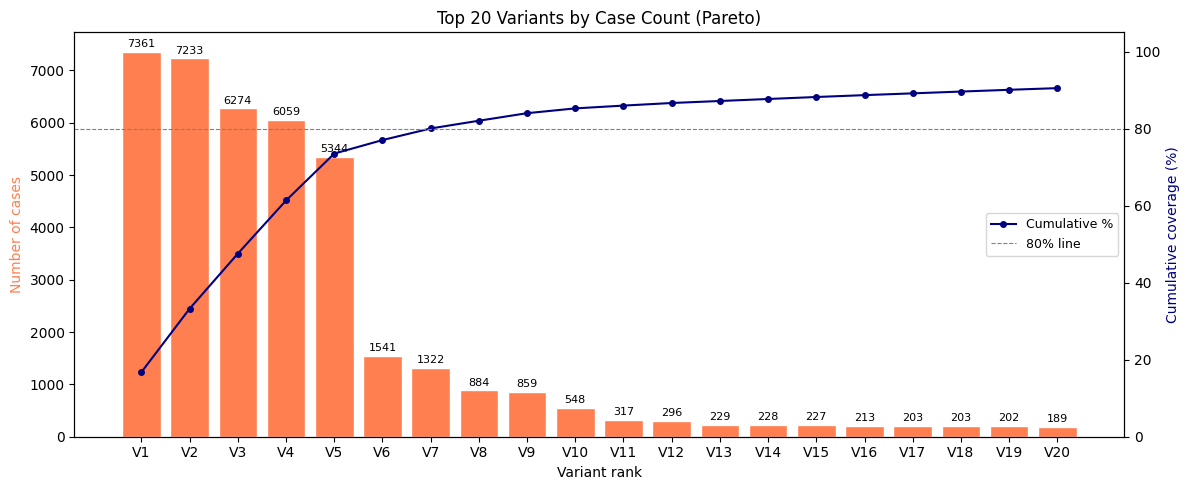

In [32]:
top20  = sorted_variants[:20]
labels = [f"V{i+1}" for i in range(len(top20))]
counts = [variant_count(v) for v in top20]
cumulative = [sum(counts[:i+1]) / total_cases * 100 for i in range(len(counts))]

fig, ax1 = plt.subplots(figsize=(12, 5))

bars = ax1.bar(labels, counts, color="coral", edgecolor="white")
ax1.bar_label(bars, fmt="%d", fontsize=8, padding=2)
ax1.set_title("Top 20 Variants by Case Count (Pareto)")
ax1.set_xlabel("Variant rank")
ax1.set_ylabel("Number of cases", color="coral")

ax2 = ax1.twinx()
ax2.plot(labels, cumulative, color="navy", marker="o",
         linewidth=1.5, markersize=4, label="Cumulative %")
ax2.axhline(80, color="gray", linestyle="--", linewidth=0.8, label="80% line")
ax2.set_ylabel("Cumulative coverage (%)", color="navy")
ax2.set_ylim(0, 105)
ax2.legend(loc="center right", fontsize=9)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "fig_03_variant_freq.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()


### 4. Throughput Time Analysis

**Throughput time** = time from the first to the last event in a case.
It measures the end-to-end duration of a process instance.

**Anomaly filtering applied:**
- Cases with fewer than 2 events are excluded (no duration can be computed)
- Cases with duration < 15 minutes (0.01 day) are excluded — likely data entry errors
- Cases above the 99th percentile (P99) are excluded — extreme outliers

This gives a realistic view of typical process durations without
being distorted by data quality issues.


In [34]:
# Cases with at least 2 events
valid = df_full.groupby("case:concept:name").filter(lambda x: len(x) >= 2)

tt = (
    valid.groupby("case:concept:name")["time:timestamp"].max()
  - valid.groupby("case:concept:name")["time:timestamp"].min()
)
throughput_days_raw = tt.dt.total_seconds() / 86400

# Remove < 15 min and top 1% outliers
p99 = throughput_days_raw.quantile(0.99)
throughput_days = throughput_days_raw[
    (throughput_days_raw > 0.01) & (throughput_days_raw <= p99)
]

removed = len(throughput_days_raw) - len(throughput_days)
print(f"Cases with >= 2 events (raw)           : {len(throughput_days_raw):,}")
print(f"Cases after anomaly filter             : {len(throughput_days):,}")
print(f"Removed (< 15 min or > P99={p99:.0f}d) : {removed:,}")
print()
print("Cleaned throughput statistics (days):")
print(throughput_days.describe().round(2).to_string())


Cases with >= 2 events (raw)           : 4,864
Cases after anomaly filter             : 3,997
Removed (< 15 min or > P99=277d) : 867

Cleaned throughput statistics (days):
count    3997.00
mean       36.67
std        47.45
min         0.01
25%         2.76
50%        17.89
75%        54.69
max       275.33


### 5. Fig 04 — Throughput Time Distribution

Two histograms are shown side by side:
- **Left (raw):** full distribution, capped at 400 days for readability.
  Shows the long tail caused by outliers and near-zero durations.
- **Right (cleaned):** after removing anomalies.
  Reveals the true shape of typical case durations.

Red dashed line = median, orange = mean.
When mean > median, the distribution is right-skewed (some very long cases pull the average up).


Saved: output\fig_04_throughput.png


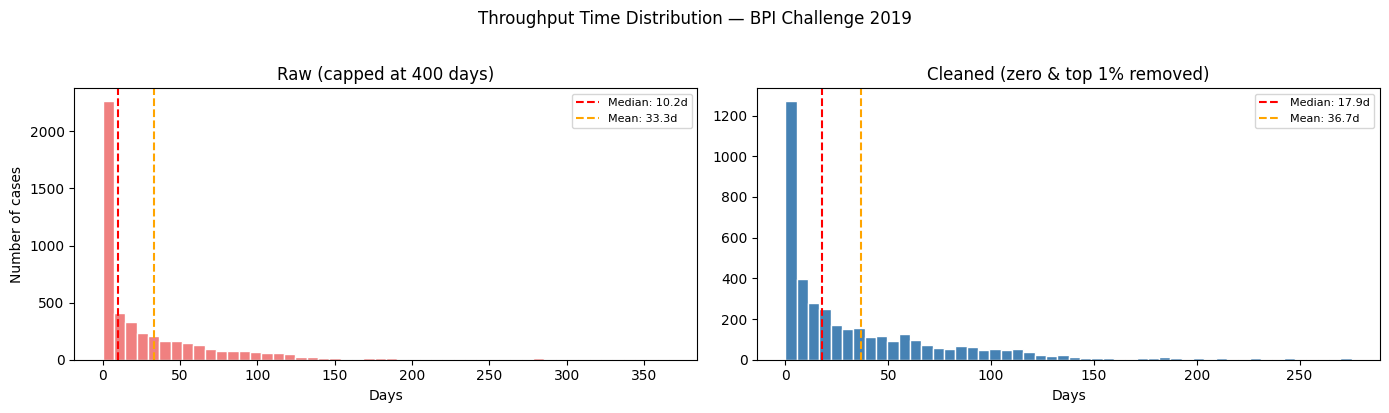

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: raw
axes[0].hist(
    throughput_days_raw[throughput_days_raw <= 400].dropna(),
    bins=50, color="lightcoral", edgecolor="white"
)
axes[0].axvline(throughput_days_raw.median(), color="red",
                linestyle="--", label=f"Median: {throughput_days_raw.median():.1f}d")
axes[0].axvline(throughput_days_raw.mean(), color="orange",
                linestyle="--", label=f"Mean: {throughput_days_raw.mean():.1f}d")
axes[0].set_title("Raw (capped at 400 days)")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Number of cases")
axes[0].legend(fontsize=8)

# Right: cleaned
axes[1].hist(throughput_days.dropna(), bins=50,
             color="steelblue", edgecolor="white")
axes[1].axvline(throughput_days.median(), color="red",
                linestyle="--", label=f"Median: {throughput_days.median():.1f}d")
axes[1].axvline(throughput_days.mean(), color="orange",
                linestyle="--", label=f"Mean: {throughput_days.mean():.1f}d")
axes[1].set_title("Cleaned (zero & top 1% removed)")
axes[1].set_xlabel("Days")
axes[1].legend(fontsize=8)

plt.suptitle("Throughput Time Distribution — BPI Challenge 2019", y=1.02)
plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "fig_04_throughput.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()


### 6. Rework / Loop Detection

**Rework** occurs when the same activity appears more than once in a single case.
This indicates re-processing — a sign of errors, rejections, or corrections
that were not intended in the original process design.

**Rework rate** = proportion of cases containing at least one repeated activity.

A high rework rate suggests:
- Quality issues upstream (invoices sent back for correction)
- Manual interventions outside the standard flow
- Process inefficiency and extra cost


In [38]:
# Sample 3,000 cases for performance
sample_cases = df_full["case:concept:name"].drop_duplicates().head(3000)
df_small     = df_full[df_full["case:concept:name"].isin(sample_cases)]

repeat_cases       = 0
repeat_act_counter = Counter()

for case_id, g in df_small.groupby("case:concept:name"):
    cnt = Counter(g["concept:name"].tolist())
    if any(v > 1 for v in cnt.values()):
        repeat_cases += 1
        for act, freq in cnt.items():
            if freq > 1:
                repeat_act_counter[act] += 1

rework_rate = repeat_cases / len(sample_cases)
print(f"Cases sampled  : {len(sample_cases):,}")
print(f"Cases with rework : {repeat_cases:,}")
print(f"Rework rate    : {rework_rate:.1%}")
print()
print("Top 10 repeated activities:")
for act, count in repeat_act_counter.most_common(10):
    print(f"  {count:>5,} cases — {act}")


Cases sampled  : 3,000
Cases with rework : 147
Rework rate    : 4.9%

Top 10 repeated activities:
    111 cases — Record Service Entry Sheet
     58 cases — Record Goods Receipt
     18 cases — Record Invoice Receipt
     11 cases — Vendor creates invoice
      6 cases — Clear Invoice
      2 cases — Change Quantity


### 7. Fig 05 — Rework Activity Chart

Shows which activities are most frequently repeated across cases.
The most reworked activity is the main bottleneck in the correction flow.

Saved: output\fig_05_rework.png


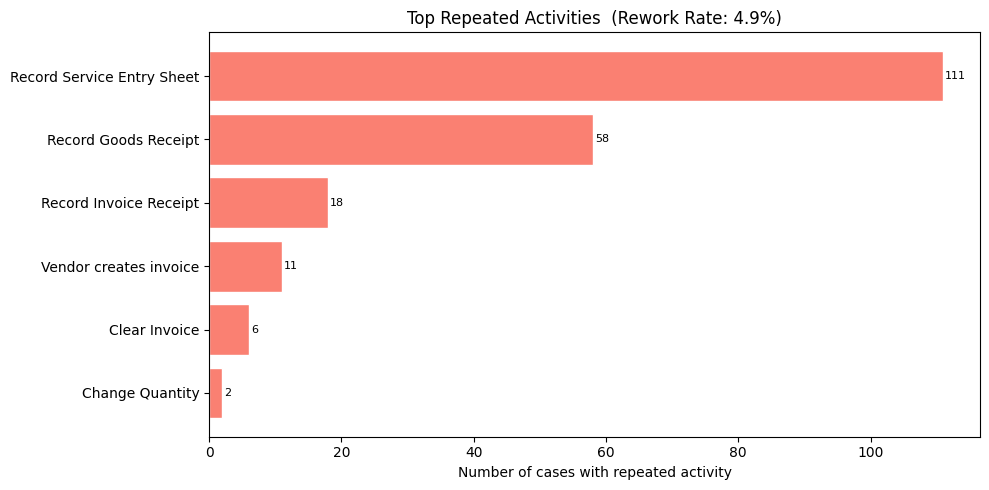

In [40]:
if repeat_act_counter:
    top_rework     = repeat_act_counter.most_common(10)
    acts_r, cnts_r = zip(*top_rework)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(list(acts_r)[::-1], list(cnts_r)[::-1], color="salmon",
            edgecolor="white")
    ax.set_title(f"Top Repeated Activities  (Rework Rate: {rework_rate:.1%})")
    ax.set_xlabel("Number of cases with repeated activity")
    for i, v in enumerate(list(cnts_r)[::-1]):
        ax.text(v + 0.3, i, str(v), va="center", fontsize=8)
    plt.tight_layout()
    fig_path = os.path.join(OUTPUT_DIR, "fig_05_rework.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()
else:
    print("No rework detected in sample.")

### 8. Fig 06 — Throughput Time by Document Type

BPI 2019 contains three document types:
- **Standard PO** — routine purchase order
- **Framework order** — blanket contract with a vendor, releases issued over time
- **EC Purchase order** — European Commission procurement format

Comparing throughput across document types reveals whether
certain procurement channels are systematically slower than others.


Throughput time by document type (days):
                    count    mean     std  min    25%     50%     75%     max
doc_type                                                                     
EC Purchase order   109.0   88.54  110.40  0.0   3.79   34.20  137.04  365.89
Framework order     184.0  164.71  109.52  0.0  57.73  177.92  258.17  366.00
Standard PO        4571.0   26.69   38.02  0.0   0.13    8.27   40.38  285.18
Saved: output\fig_06_throughput_by_doctype.png


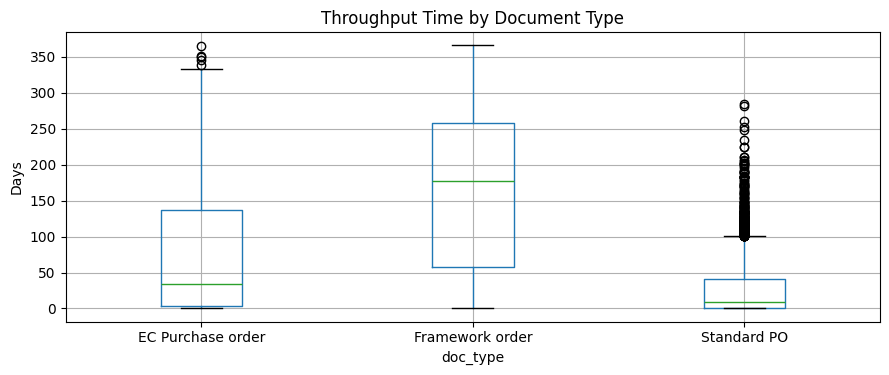

In [42]:
doc_type_tt = (
    df_full[df_full["case:concept:name"].isin(valid["case:concept:name"])]
    .groupby("case:concept:name")
    .agg(
        doc_type=("cDocType", "first"),
        tt_days=(
            "time:timestamp",
            lambda x: (x.max() - x.min()).total_seconds() / 86400
        )
    )
    .reset_index()
)

print("Throughput time by document type (days):")
print(doc_type_tt.groupby("doc_type")["tt_days"]
      .describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
doc_type_tt.boxplot(column="tt_days", by="doc_type", ax=ax)
ax.set_title("Throughput Time by Document Type")
ax.set_ylabel("Days")
plt.suptitle("")
plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "fig_06_throughput_by_doctype.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()


### 9. KPI Summary Table

Consolidated view of all key metrics computed in this notebook.
This table can be used directly in the thesis as a performance dashboard.


In [44]:
summary = pd.DataFrame({
    "Metric": [
        "Dataset",
        "Object type used",
        "Total cases (after filter)",
        "Total events (after filter)",
        "Total distinct variants",
        "Top-10 variant coverage",
        "Top-20 variant coverage",
        "Cases with >= 2 events (raw)",
        "Cases after anomaly filter",
        "Mean throughput (days)",
        "Median throughput (days)",
        "P95 throughput (days)",
        "Min throughput (days)",
        "Max throughput (days)",
        "Rework rate (sample 3,000)"
    ],
    "Value": [
        os.path.basename(OCEL_PATH),
        most_common_type,
        f"{df_full['case:concept:name'].nunique():,}",
        f"{len(df_full):,}",
        f"{len(variants):,}",
        f"{top10_cases/total_cases:.1%}",
        f"{top20_cases/total_cases:.1%}",
        f"{len(throughput_days_raw):,}",
        f"{len(throughput_days):,}",
        f"{throughput_days.mean():.2f}",
        f"{throughput_days.median():.2f}",
        f"{throughput_days.quantile(0.95):.2f}",
        f"{throughput_days.min():.2f}",
        f"{throughput_days.max():.2f}",
        f"{rework_rate:.1%}"
    ]
})

print("=== Advanced Analysis — KPI Summary ===")
display(summary)

=== Advanced Analysis — KPI Summary ===


,Metric,Value
0,Dataset,BPIC19_sample.jsonocel
1,Object type used,POItem
2,Total cases (after filter),"43,898"
3,Total events (after filter),"53,187"
4,Total distinct variants,776
5,Top-10 variant coverage,85.3%
6,Top-20 variant coverage,90.5%
7,Cases with >= 2 events (raw),"4,864"
8,Cases after anomaly filter,"3,997"
9,Mean throughput (days),36.67



### Figures saved to output folder

| Figure | File | Description |
|--------|------|-------------|
| Fig 03 | `fig_03_variant_freq.png` | Variant frequency + Pareto line |
| Fig 04 | `fig_04_throughput.png` | Throughput distribution (raw vs cleaned) |
| Fig 05 | `fig_05_rework.png` | Top repeated activities |
| Fig 06 | `fig_06_throughput_by_doctype.png` | Throughput by document type |
